In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 3.7 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.9 MB 4.1 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.9 MB 3.6 MB/s eta 0:00:03
   ----------- ---------------------------- 2.9/9.9 MB 3.5 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.9 MB 3.3 MB/s eta 0:00:03
   --------------- ------------------------ 3.9/9.9 MB 3.1 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.9 MB 3.2 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 3.2 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.9 MB 3.3 MB/s eta 0:00:02
   ---------------------------- ----------- 7.1/9.9 MB 3.3 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 3.4 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.9 MB 3.4 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier

Matplotlib is building the font cache; this may take a moment.


In [10]:
df = pd.read_csv("customer_shopping_behavior.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [12]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='str')

In [13]:
df.shape

(3900, 18)

In [14]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


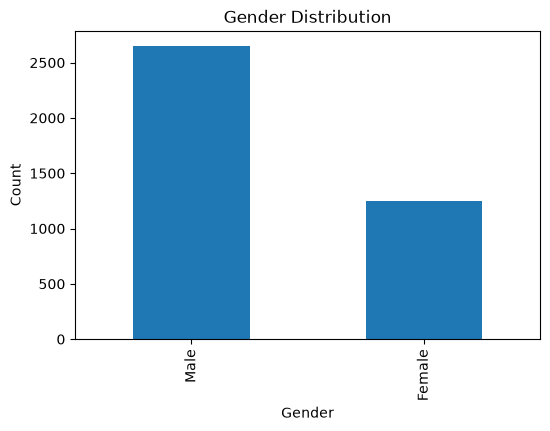

In [17]:
plt.figure(figsize=(6,4))
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

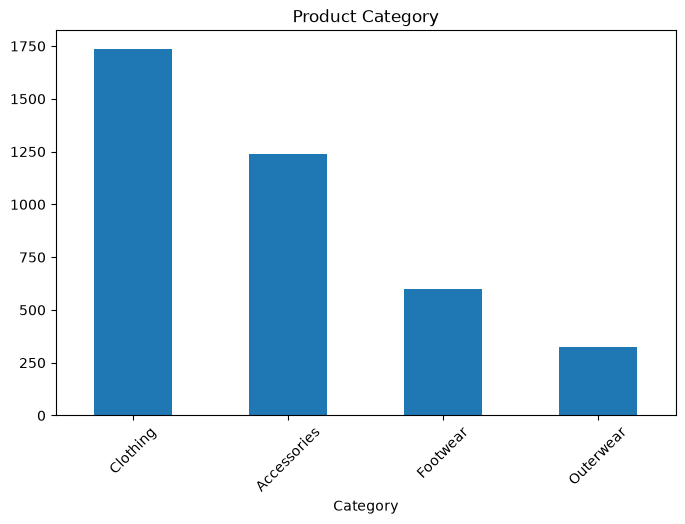

In [18]:
plt.figure(figsize=(8,5))
df["Category"].value_counts().plot(kind="bar")
plt.title("Product Category")
plt.xticks(rotation=45)
plt.show()

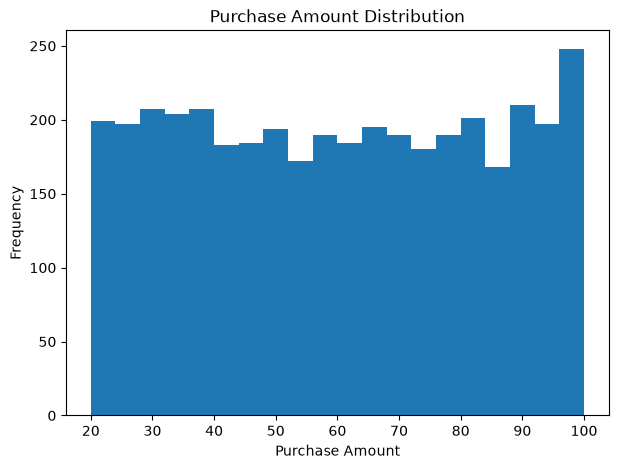

In [19]:
plt.figure(figsize=(7,5))
plt.hist(df["Purchase Amount (USD)"], bins=20)
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

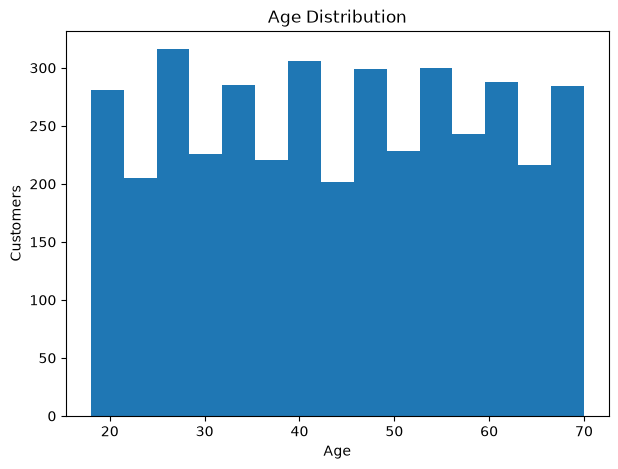

In [20]:
plt.figure(figsize=(7,5))
plt.hist(df["Age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")
plt.show()

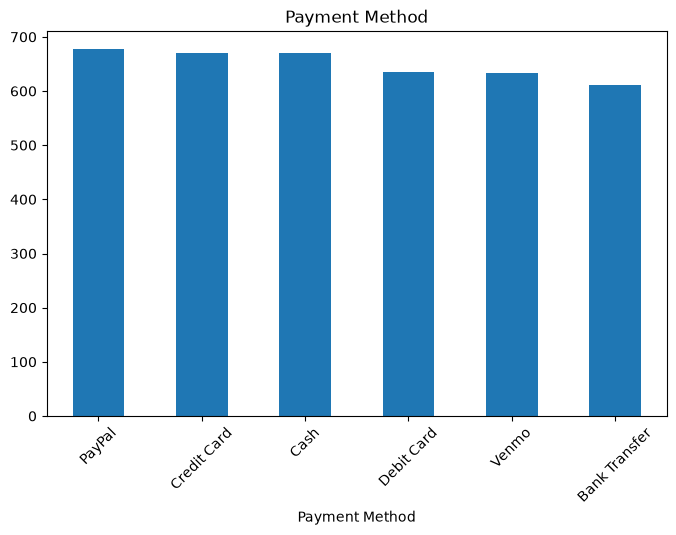

In [21]:
plt.figure(figsize=(8,5))
df["Payment Method"].value_counts().plot(kind="bar")
plt.title("Payment Method")
plt.xticks(rotation=45)
plt.show()

In [22]:
df.groupby("Gender")["Purchase Amount (USD)"].mean()

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64

In [23]:
df["Location"].value_counts().head(10)

Location
Montana       96
California    95
Idaho         93
Illinois      92
Alabama       89
Minnesota     88
New York      87
Nevada        87
Nebraska      87
Delaware      86
Name: count, dtype: int64

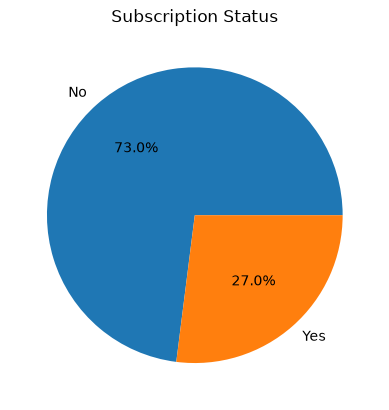

In [24]:
df["Subscription Status"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Subscription Status")
plt.show()

In [25]:
df["Item Purchased"].value_counts().head(10)

Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: count, dtype: int64

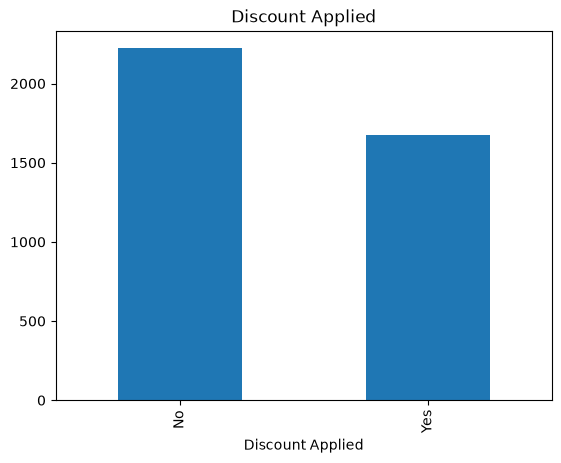

In [26]:
df["Discount Applied"].value_counts().plot(kind="bar")
plt.title("Discount Applied")
plt.show()

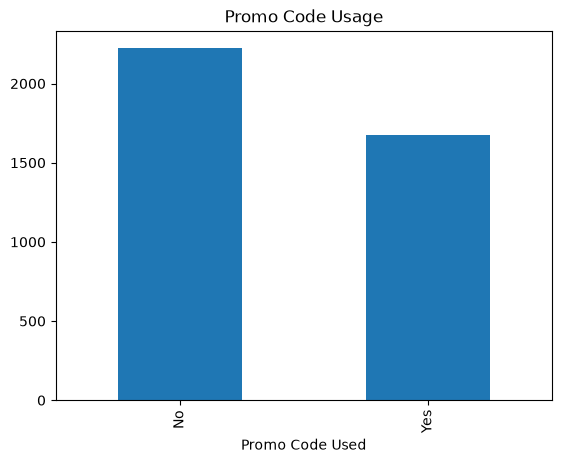

In [27]:
df["Promo Code Used"].value_counts().plot(kind="bar")
plt.title("Promo Code Usage")
plt.show()

In [28]:
total_revenue = df["Purchase Amount (USD)"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 233081


In [29]:
average_purchase = df["Purchase Amount (USD)"].mean()

print("Average Purchase:", average_purchase)

Average Purchase: 59.76435897435898


In [29]:
average_purchase = df["Purchase Amount (USD)"].mean()

print("Average Purchase:", average_purchase)

Average Purchase: 59.76435897435898


In [ ]:
Business Insights

1. Most customers prefer shopping in the Clothing category.

2. Credit Card is the most preferred payment method.

3. Average purchase amount is approximately XX USD.

4. Most customers are not subscribed.

5. Discounts increase customer purchases.

6. Businesses should focus on high-demand categories and offer personalized promotions.

In [ ]:
## Conclusion

The analysis shows customer purchasing trends, preferred product categories, payment methods, subscription behavior, and regional demand. These insights can help businesses improve marketing strategies, optimize inventory, and enhance customer satisfaction.